# Aula 5 — IDHM por Unidade da Federação com matplotlib

Tabela com o **IDHM (Índice de Desenvolvimento Humano Municipal)** de cada estado brasileiro de 1991 a 2024.

**Roteiro:**
1. Abrir um CSV com `;` e vírgula decimal
2. Limpar colunas vazias
3. Ordenar os estados por maior IDH em 2024
4. Qual estado teve a maior melhora de IDH entre 1991 e 2024?
5. Existe algum estado em que o IDH piorou?
6. Passar a tabela do formato largo para o formato longo (`melt`)
7. Plotar apenas Minas Gerais
8. Plotar a evolução do IDH de cada estado

In [1]:
# No terminal, uma vez: python -m pip install pandas matplotlib
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# arquivo na mesma pasta do notebook
path = "Tabela4.csv"

## 1 - Abrindo o CSV com `;` e vírgula decimal

O arquivo tem algumas particularidades:
- separador é `;` (e não `,`) → `sep=";"`
- números usam **vírgula** como decimal (`0,402`) → `decimal=","`
- foi salvo no Excel em português, com acentos em `latin-1` → `encoding="latin-1"`

Primeiro, veja o que acontece lendo "do jeito padrão": a 1ª linha (o título) vira o cabeçalho e aparecem várias colunas `Unnamed`.

In [3]:
bruto = pd.read_csv(path, sep=";", decimal=",", encoding="latin-1")
bruto.head()

,IDHM - Índice de Desenvolvimento Humano Municipal,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18
0,Sigla,Código,Estado,1991.000,2000.000,2010.000,2012.000,2013.000,2014.000,2015.000,2016.000,2017.000,2018.000,2019.000,2020.000,2021.000,2022.000,2023.000,2024.000
1,AC,12,Acre,0.402,0.517,0.663,0.705,0.709,0.719,0.719,0.723,0.711,0.731,0.738,0.736,0.702,0.732,0.740,0.754
2,AL,27,Alagoas,0.370,0.471,0.631,0.657,0.653,0.670,0.669,0.680,0.682,0.694,0.693,0.694,0.691,0.722,0.739,0.746
3,AM,13,Amazonas,0.430,0.515,0.674,0.706,0.717,0.720,0.724,0.723,0.743,0.732,0.739,0.725,0.700,0.757,0.764,0.767
4,AP,16,Amapá,0.472,0.577,0.708,0.709,0.735,0.726,0.728,0.732,0.731,0.737,0.732,0.707,0.681,0.743,0.767,0.759


A linha com os nomes de verdade (`Sigla`, `Código`, `Estado`, anos…) é a 2ª linha do arquivo. Usamos `skiprows=1` para pular o título:

In [4]:
df = pd.read_csv(path, sep=";", decimal=",", encoding="latin-1", skiprows=1)
df.head()

,Sigla,Código,Estado,1991,2000,2010,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,AC,12,Acre,0.402,0.517,0.663,0.705,0.709,0.719,0.719,0.723,0.711,0.731,0.738,0.736,0.702,0.732,0.740,0.754
1,AL,27,Alagoas,0.370,0.471,0.631,0.657,0.653,0.670,0.669,0.680,0.682,0.694,0.693,0.694,0.691,0.722,0.739,0.746
2,AM,13,Amazonas,0.430,0.515,0.674,0.706,0.717,0.720,0.724,0.723,0.743,0.732,0.739,0.725,0.700,0.757,0.764,0.767
3,AP,16,Amapá,0.472,0.577,0.708,0.709,0.735,0.726,0.728,0.732,0.731,0.737,0.732,0.707,0.681,0.743,0.767,0.759
4,BA,29,Bahia,0.386,0.512,0.660,0.684,0.686,0.700,0.708,0.708,0.715,0.714,0.723,0.726,0.698,0.734,0.740,0.759


## 2 - Limpando colunas vazias

`dropna(axis=1, how="all")` remove as colunas em que **todos** os valores são vazios. Também removemos linhas totalmente vazias, se houver.

In [5]:
print("Antes :", df.shape)

df = df.dropna(axis=1, how="all")   # colunas 100% vazias
df = df.dropna(axis=0, how="all")   # linhas 100% vazias
df.columns = df.columns.str.strip() # tira espaços sobrando nos nomes

print("Depois:", df.shape)
print(df.dtypes)

Antes : (27, 19)
Depois: (27, 19)
Sigla         str
Código      int64
Estado        str
1991      float64
2000      float64
2010      float64
2012      float64
2013      float64
2014      float64
2015      float64
2016      float64
2017      float64
2018      float64
2019      float64
2020      float64
2021      float64
2022      float64
2023      float64
2024      float64
dtype: object


As colunas dos anos já vieram como `float64`, então o `decimal=","` funcionou e os IDHs são números.

## 3 - Estados ordenados por maior IDH em 2024

In [6]:
ranking_2024 = (
    df[["Sigla", "Estado", "2024"]]
    .sort_values("2024", ascending=False)
    .reset_index(drop=True)
)
ranking_2024.index = ranking_2024.index + 1  # posição começando em 1
ranking_2024

,Sigla,Estado,2024
1,DF,Distrito Federal,0.866
2,SP,São Paulo,0.838
3,SC,Santa Catarina,0.833
4,PR,Paraná,0.822
5,RJ,Rio de Janeiro,0.819
6,RS,Rio Grande do Sul,0.818
7,GO,Goiás,0.815
8,MT,Mato Grosso,0.812
9,MG,Minas Gerais,0.809
10,ES,Espírito Santo,0.804


## 4 - Qual estado teve a maior melhora de IDH entre 1991 e 2024?

In [7]:
df["melhora_1991_2024"] = df["2024"] - df["1991"]
df["melhora_%"] = (df["melhora_1991_2024"] / df["1991"] * 100).round(1)

melhora = df[["Sigla", "Estado", "1991", "2024", "melhora_1991_2024", "melhora_%"]] \
    .sort_values("melhora_1991_2024", ascending=False).reset_index(drop=True)

top = melhora.iloc[0]
print(f"Maior melhora: {top['Estado']} ({top['Sigla']})")
print(f"IDH foi de {top['1991']:.3f} em 1991 para {top['2024']:.3f} em 2024 "
      f"(+{top['melhora_1991_2024']:.3f} pontos, +{top['melhora_%']}%)")

melhora

Maior melhora: Tocantins (TO)
IDH foi de 0.369 em 1991 para 0.797 em 2024 (+0.428 pontos, +116.0%)


,Sigla,Estado,1991,2024,melhora_1991_2024,melhora_%
0,TO,Tocantins,0.369,0.797,0.428,116.0
1,PI,Piauí,0.362,0.764,0.402,111.0
2,MA,Maranhão,0.357,0.745,0.388,108.7
3,RO,Rondônia,0.407,0.786,0.379,93.1
4,PB,Paraíba,0.382,0.760,0.378,99.0
5,AL,Alagoas,0.370,0.746,0.376,101.6
6,BA,Bahia,0.386,0.759,0.373,96.6
7,CE,Ceará,0.405,0.773,0.368,90.9
8,MT,Mato Grosso,0.449,0.812,0.363,80.8
9,SE,Sergipe,0.408,0.761,0.353,86.5


## 5 - Existe algum estado em que o IDH piorou?

Vamos olhar de duas formas:
- **1991 → 2024** (período inteiro)
- **2023 → 2024** (último ano)

In [8]:
piorou_total = df[df["2024"] < df["1991"]]
print(f"Estados que pioraram entre 1991 e 2024: {len(piorou_total)}")

Estados que pioraram entre 1991 e 2024: 0


In [9]:
df["variacao_2023_2024"] = (df["2024"] - df["2023"]).round(3)
piorou_ultimo_ano = df.loc[df["variacao_2023_2024"] < 0, ["Sigla", "Estado", "2023", "2024", "variacao_2023_2024"]]

print(f"Estados que pioraram entre 2023 e 2024: {len(piorou_ultimo_ano)}")
piorou_ultimo_ano

Estados que pioraram entre 2023 e 2024: 2


,Sigla,Estado,2023,2024,variacao_2023_2024
3,AP,Amapá,0.767,0.759,-0.008
6,DF,Distrito Federal,0.870,0.866,-0.004


**Resposta:** no período todo (1991 → 2024), **nenhum estado piorou**: todos melhoraram bastante.
Mas, olhando só o último ano (2023 → 2024), alguns estados tiveram uma pequena queda.

Também dá para ver no gráfico mais abaixo uma queda geral em **2020–2021**, provavelmente efeito da pandemia.

## 6 - Do formato largo para o formato longo (`melt`)

- **Largo:** 1 linha por estado, 1 coluna por ano (bom para ler)
- **Longo:** 1 linha por **estado + ano** (bom para gráficos e `groupby`)

Antes, removemos as colunas de cálculo que criamos, para voltar à tabela inicial.

In [10]:
df = df.drop(columns=["melhora_1991_2024", "melhora_%", "variacao_2023_2024"])

anos = [c for c in df.columns if str(c).isdigit()]
print(anos)

id_vars = [c for c in df.columns if c not in anos]
df_longo = df.melt(
    id_vars=id_vars,
    value_vars=anos,
    var_name="Ano",
    value_name="IDH",
)
df_longo["Ano"] = df_longo["Ano"].astype(int)
df_longo["IDH"] = pd.to_numeric(df_longo["IDH"], errors="coerce")

print(f"Largo: {df.shape}  ->  Longo: {df_longo.shape}")
df_longo.head()

['1991', '2000', '2010', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
Largo: (27, 19)  ->  Longo: (432, 5)


,Sigla,Código,Estado,Ano,IDH
0,AC,12,Acre,1991,0.402
1,AL,27,Alagoas,1991,0.370
2,AM,13,Amazonas,1991,0.430
3,AP,16,Amapá,1991,0.472
4,BA,29,Bahia,1991,0.386


## 7 - Plotando apenas Minas Gerais

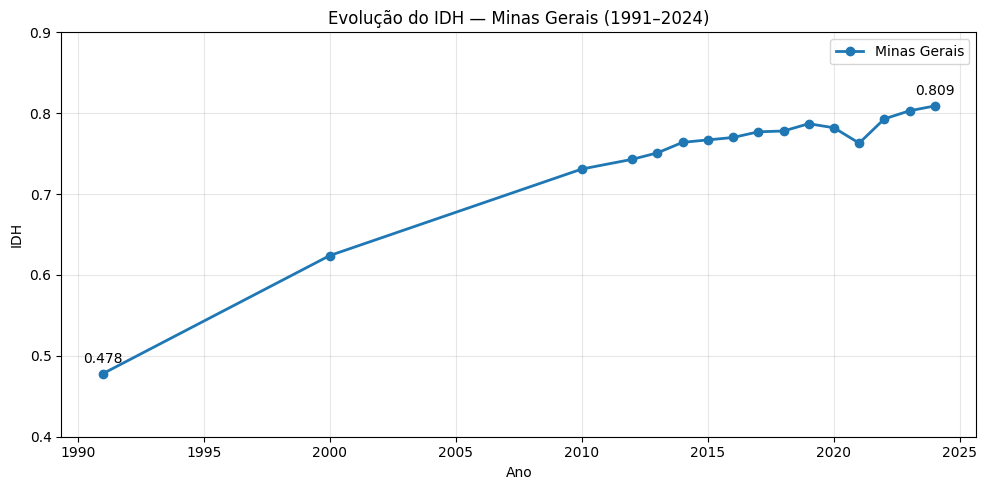

In [11]:
mg = df_longo[df_longo["Sigla"] == "MG"].sort_values("Ano")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(mg["Ano"], mg["IDH"], marker="o", linewidth=2, color="tab:blue", label="Minas Gerais")

# destaca o primeiro e o último valor
for ano in [mg["Ano"].min(), mg["Ano"].max()]:
    valor = mg.loc[mg["Ano"] == ano, "IDH"].item()
    ax.annotate(f"{valor:.3f}", (ano, valor), textcoords="offset points", xytext=(0, 8), ha="center")

ax.set_title("Evolução do IDH — Minas Gerais (1991–2024)")
ax.set_xlabel("Ano")
ax.set_ylabel("IDH")
ax.set_ylim(0.4, 0.9)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig("idh_minas_gerais.png", dpi=150)
plt.show()

Os anos **não têm intervalos iguais** (1991, 2000, 2010 e depois anual), por isso a linha tem trechos mais longos no começo. Como o eixo X usa o ano como número, as distâncias no gráfico ficam proporcionais ao tempo.

## 8 - Evolução do IDH de cada estado

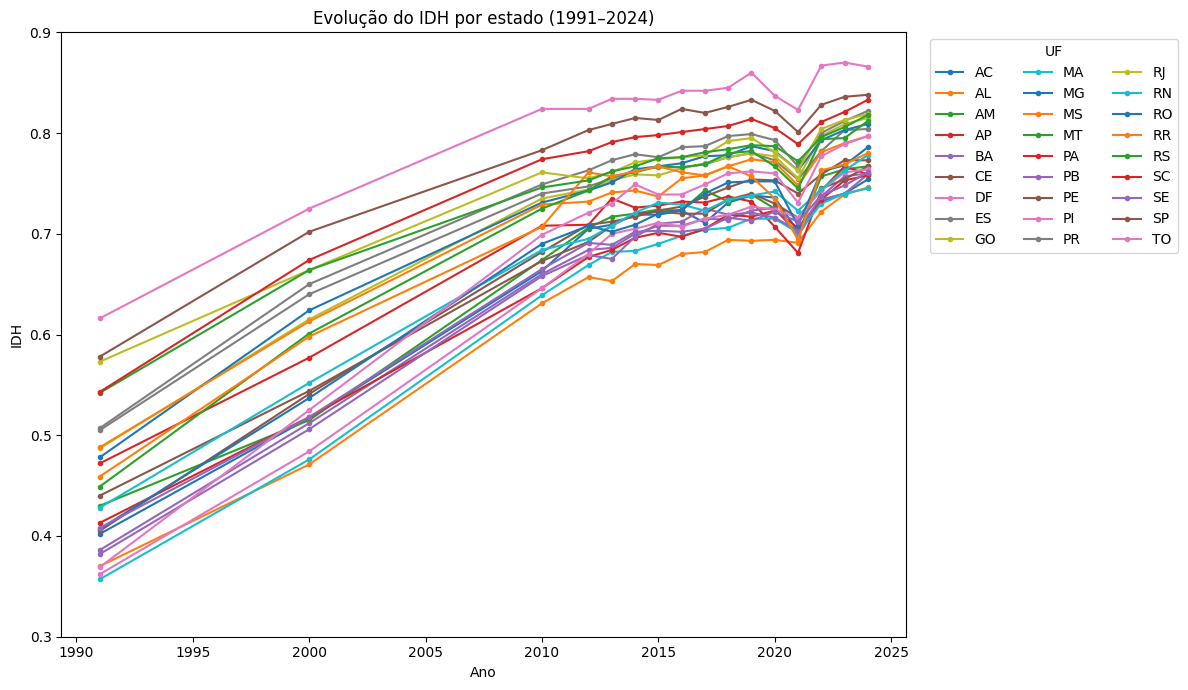

In [12]:
fig, ax = plt.subplots(figsize=(12, 7))

for sigla, grupo in df_longo.groupby("Sigla"):
    grupo = grupo.sort_values("Ano")
    ax.plot(grupo["Ano"], grupo["IDH"], marker="o", markersize=3, linewidth=1.5, label=sigla)

ax.set_title("Evolução do IDH por estado (1991–2024)")
ax.set_xlabel("Ano")
ax.set_ylabel("IDH")
ax.set_ylim(0.3, 0.9)
ax.legend(ncol=3, bbox_to_anchor=(1.02, 1), loc="upper left", title="UF")
fig.tight_layout()
fig.savefig("idh_todos_estados.png", dpi=150, bbox_inches="tight")
plt.show()

Com 27 linhas as cores se repetem e fica difícil identificar cada estado. Uma alternativa é deixar todos em cinza e **destacar só alguns** (maior IDH, menor IDH e MG):

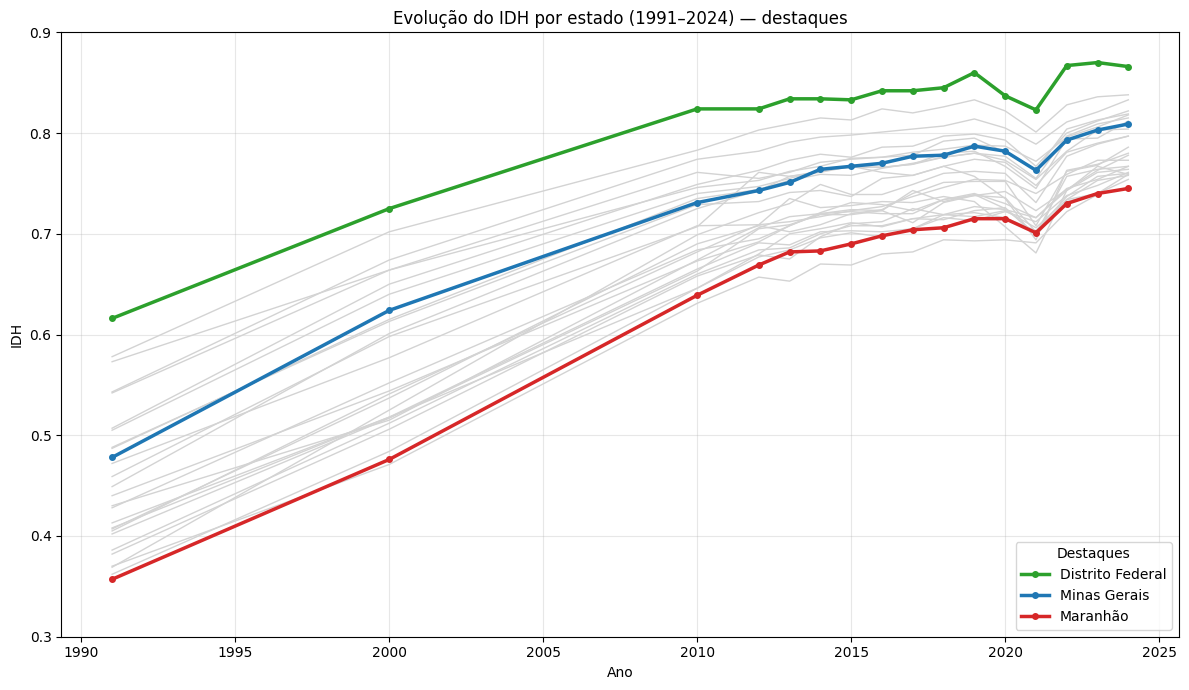

In [13]:
destaques = {"DF": "tab:green", "MG": "tab:blue", "MA": "tab:red"}

fig, ax = plt.subplots(figsize=(12, 7))

for sigla, grupo in df_longo.groupby("Sigla"):
    grupo = grupo.sort_values("Ano")
    if sigla in destaques:
        continue
    ax.plot(grupo["Ano"], grupo["IDH"], color="lightgray", linewidth=1)

for sigla, cor in destaques.items():
    grupo = df_longo[df_longo["Sigla"] == sigla].sort_values("Ano")
    ax.plot(grupo["Ano"], grupo["IDH"], color=cor, linewidth=2.5, marker="o", markersize=4,
            label=grupo["Estado"].iloc[0])

ax.set_title("Evolução do IDH por estado (1991–2024) — destaques")
ax.set_xlabel("Ano")
ax.set_ylabel("IDH")
ax.set_ylim(0.3, 0.9)
ax.grid(alpha=0.3)
ax.legend(title="Destaques", loc="lower right")
fig.tight_layout()
fig.savefig("idh_destaques.png", dpi=150)
plt.show()